## Describe Data Dataset Iris

Pada bagian ini dilakukan analisis statistik deskriptif untuk memahami karakteristik numerik dari dataset Iris. Statistik deskriptif membantu melihat nilai rata-rata, minimum, maksimum, serta penyebaran data.

In [6]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['species'] = iris.target

data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Statistik Deskriptif

Berikut adalah hasil statistik deskriptif dari dataset Iris:

In [7]:
import pandas as pd
from sklearn.datasets import load_iris
from scipy import stats

# Load dataset Iris
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

# List untuk menyimpan ringkasan
summary_list = []

for col in iris.feature_names:
    mean = round(data[col].mean(), 2)
    median = round(data[col].median(), 2)
    mode = stats.mode(data[col], keepdims=True).mode[0]
    std = round(data[col].std(), 2)
    min_val = data[col].min()
    max_val = data[col].max()
    var = round(data[col].var(), 2)
    
    summary_list.append({
        'Feature': col,
        'Mean': mean,
        'Median': median,
        'Mode': mode,
        'Std': std,
        'Min': min_val,
        'Max': max_val,
        'Variance': var
    })

# Ubah list menjadi DataFrame
summary = pd.DataFrame(summary_list)
summary

,Feature,Mean,Median,Mode,Std,Min,Max,Variance
0,sepal length (cm),5.84,5.80,5.0,0.83,4.3,7.9,0.69
1,sepal width (cm),3.06,3.00,3.0,0.44,2.0,4.4,0.19
2,petal length (cm),3.76,4.35,1.4,1.77,1.0,6.9,3.12
3,petal width (cm),1.20,1.30,0.2,0.76,0.1,2.5,0.58


### Penjelasan:

- **Mean** menunjukkan rata-rata dari setiap variabel.
- **Min dan Max** menunjukkan nilai terkecil dan terbesar.
- **Std (Standar Deviasi)** menunjukkan tingkat penyebaran data.
- Variabel petal length dan petal width memiliki variasi yang cukup besar dibandingkan sepal width.

Dari hasil ini dapat disimpulkan bahwa setiap variabel memiliki rentang nilai yang berbeda dan dapat digunakan untuk membedakan spesies bunga.

## Pemeriksaan Missing Value

Hasil menunjukkan bahwa tidak terdapat data yang kosong (missing value) pada dataset Iris, sehingga data siap untuk analisis lanjutan.

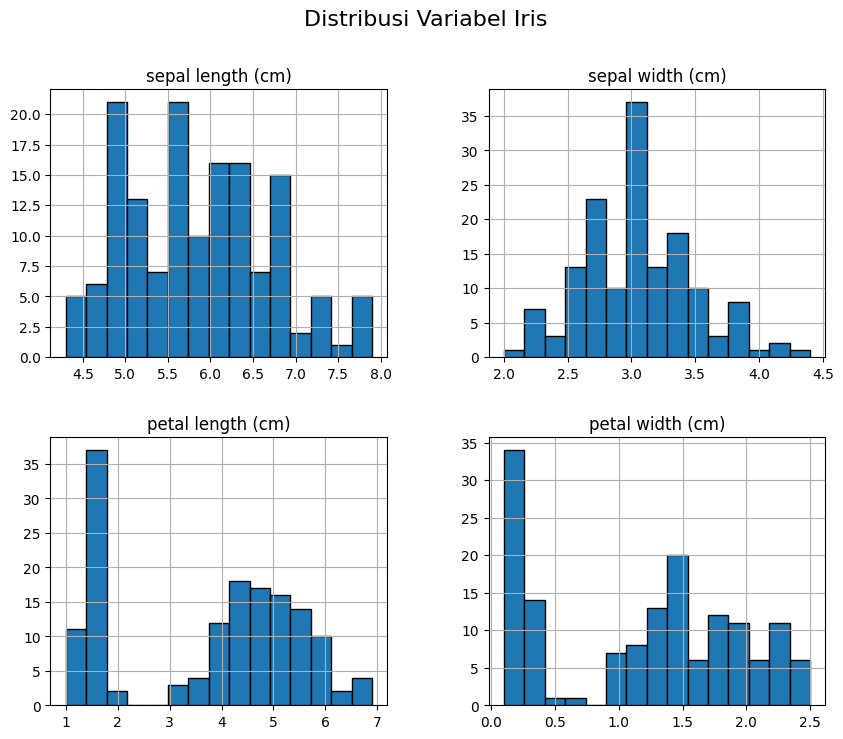

In [8]:
import matplotlib.pyplot as plt
data.drop(columns='species', errors='ignore').hist(figsize=(10,8), bins=15, edgecolor='black')
plt.suptitle('Distribusi Variabel Iris', fontsize=16)
plt.show()

## Mengukur Distance Menggunakan Orange

Untuk menghitung jarak antar data pada dataset IRIS, digunakan software **Orange Data Mining**. Proses ini bertujuan untuk mengetahui tingkat kemiripan atau perbedaan antar objek berdasarkan atribut numerik.

### Langkah-langkah

1. Buka aplikasi **Orange**  
2. Tambahkan widget **File**  
3. Pilih dataset bawaan **iris**  
4. Tambahkan widget **Distances**  
5. Hubungkan `File → Distances`  
6. Pilih metode jarak (Euclidean, Manhattan, atau Cosine)  
7. Hubungkan ke: Distance Map

---

## Konsep Perhitungan Distance

### Euclidean Distance

$$
d(x,y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$

### Manhattan Distance

$$
d(x,y) = \sum_{i=1}^{n} |x_i - y_i|
$$

### Cosine Similarity

$$
\text{cosine similarity} =
\frac{x \cdot y}{||x|| \, ||y||}
$$

### Cosine Distance

$$
\text{cosine distance} = 1 - \text{cosine similarity}
$$

---

## Output Distance Matrix

Widget **Distances** menghasilkan matriks jarak (distance matrix) yang berisi jarak antar setiap pasangan data.

Karakteristik matriks jarak:

- Nilai kecil → data semakin mirip  
- Nilai besar → data semakin berbeda  
- Elemen diagonal selalu bernilai:

$$
d(x,x) = 0
$$

karena jarak suatu data terhadap dirinya sendiri adalah nol.

---

# Interpretasi Hasil Distance

## Kemiripan Dalam Spesies

Data dengan spesies yang sama (misalnya *setosa*) memiliki nilai jarak yang relatif kecil. Hal ini menunjukkan bahwa karakteristik bunga dalam satu spesies cenderung homogen.

## Perbedaan Antar Spesies

Data dari spesies berbeda (misalnya *setosa* dan *virginica*) memiliki nilai jarak yang lebih besar.

Atribut yang paling berkontribusi terhadap perbedaan tersebut adalah:

- Petal Length  
- Petal Width  

Karena kedua atribut ini memiliki variasi nilai yang signifikan antar spesies.

## Visualisasi Distance Map

Pada widget **Distance Map**:
![alt text](foto1.png)
- Warna lebih gelap → jarak kecil (lebih mirip)  
- Warna lebih terang → jarak besar (lebih berbeda)  

Biasanya terlihat blok gelap di sepanjang diagonal matriks yang menunjukkan adanya pengelompokan alami berdasarkan spesies.

# Pengukuran Jarak pada Data Campuran

Pada bagian ini dibuat contoh data campuran yang terdiri dari atribut numerik, ordinal, dan kategorikal. Metode yang digunakan adalah **Gower Distance** karena mampu menangani berbagai tipe atribut dalam satu perhitungan.

---

# Contoh Data Campuran

| ID  | Umur (Numerik) | IPK (Numerik) | Semester (Ordinal) | Jurusan (Kategorikal) |
|-----|---------------|---------------|--------------------|------------------------|
| M1  | 20            | 3.50          | 4                  | Informatika           |
| M2  | 22            | 3.80          | 6                  | Sistem Informasi      |
| M3  | 21            | 3.20          | 4                  | Informatika           |
| M4  | 23            | 3.60          | 8                  | Teknik Industri       |
| M5  | 19            | 3.00          | 2                  | Informatika           |
| M6  | 24            | 3.90          | 8                  | Sistem Informasi      |
| M7  | 20            | 3.40          | 4                  | Teknik Industri       |
| M8  | 22            | 3.70          | 6                  | Informatika           |
| M9  | 21            | 3.10          | 2                  | Sistem Informasi      |
| M10 | 23            | 3.85          | 8                  | Informatika           |

---

# Metode Pengukuran: Gower Distance

Rumus umum Gower Distance:

$$
D_{ij} = \frac{\sum_{k=1}^{p} s_{ijk}}{p}
$$

Keterangan:

- $D_{ij}$ = jarak antara objek $i$ dan $j$
- $p$ = jumlah atribut
- $s_{ijk}$ = skor jarak atribut ke-$k$

---

# Perhitungan Setiap Tipe Atribut

## 1. Atribut Numerik

Untuk atribut numerik digunakan normalisasi:

$$
s_{ijk} = \frac{|x_{ik} - x_{jk}|}{\text{range}_k}
$$

Range dihitung dengan:

$$
\text{range}_k = \text{max}_k - \text{min}_k
$$

---

## 2. Atribut Ordinal

Karena semester bersifat berurutan (2, 4, 6, 8), maka dihitung seperti numerik setelah dinormalisasi.

---

## 3. Atribut Kategorikal

Untuk atribut kategorikal:

$$
s_{ijk} =
\begin{cases}
0, & \text{jika kategori sama} \\
1, & \text{jika kategori berbeda}
\end{cases}
$$

---

# Contoh Perhitungan Jarak M1 dan M2

## Langkah 1: Hitung Range

Umur:

$$
24 - 19 = 5
$$

IPK:

$$
3.90 - 3.00 = 0.90
$$

Semester:

$$
8 - 2 = 6
$$

---

## Langkah 2: Hitung Selisih Ternormalisasi

Umur:

$$
\frac{|20 - 19|}{5} = 0.2
$$

IPK:

$$
\frac{|3.50 - 3.00|}{0.90} = 0.55
$$

Semester:

$$
\frac{|4 - 2|}{6} = 0.33
$$

Jurusan (Informatika vs Sistem Informasi):

$$
s = 1
$$

---

## Langkah 3: Hitung Gower Distance

$$
D_{M1,M2} = \frac{0.2 + 0.55 + 0.33 + 1}{4}
$$

$$
D_{M1,M2} = 0.52
$$

---

# Interpretasi Hasil

Rentang nilai Gower Distance:

$$
0 \leq D_{ij} \leq 1
$$

- Nilai mendekati 0 → objek sangat mirip  
- Nilai mendekati 1 → objek sangat berbeda  

Nilai 0.515 menunjukkan bahwa M1 dan M2 memiliki tingkat perbedaan sedang.

## Menghitung jarak (kosongkan 1 nilai)
| ID   | Umur | IPK  | Semester | Jurusan            |     Jarak sebelom diksoongkan |Jarak setelah dikosongkan  |
| ---- | ---- | ---- | -------- | ------------------ | --- | ------- |
| M1  | 20   | 3.50 | 4        | Informatika        |   0.50476  | 0.52976 |
| M2  | 22   | 3.80 | 6        | Sistem Informasi   |  0.5381   | 0.5506  |
| M3  | 21   | 3.20 | 4        | Informatika        |  0.60397   | 0.62897 |
| M4  | 23   | 3.60 | 8        | Teknik Industri    | 0.83095    | 0.88095 |
| M5  | 19   | 3.00 | 2        | Informatika        | 0.96429    | 1.90179 |
| M6  |      | 3.90 | 8        | Sistem Informatika | 0.73175    | 1.78175 |
| M7  | 20   | 3.40 | 4        | Teknik Industri    | 0.50476    | 0.52976 |
| M8  | 22   | 3.70 | 6        | Informatika        | 0.60952    | 0.62202 |
| M9  | 21   | 3.10 | 2        | Sistem Informasi   | 0.77262    | 0.79762 |
| M10 | 23   | 3.85 | 8        | Informatika        | 2.75516    | 3.04266 |


Nilai awal umur pada id M6 = 24
---

# Kesimpulan

Gower Distance efektif digunakan pada data campuran karena mampu menggabungkan atribut numerik, ordinal, dan kategorikal dalam satu ukuran jarak terintegrasi.